# Evaluación HPC y Cloud Computing para detección de ciberataques

Este notebook implementa un pipeline experimental para evaluar modelos de machine learning aplicados a la detección de ciberataques usando el dataset UNSW-NB15.

El objetivo no es únicamente medir la calidad predictiva de los modelos, sino también analizar su rendimiento computacional. Por ello, se registran tiempos de carga, preprocesamiento, entrenamiento e inferencia, además de métricas de clasificación y optimización de memoria.

El flujo del notebook sigue la lógica:

EDA → hallazgos → decisiones de preprocesamiento → dataset final → modelos base → modelos optimizados → métricas HPC/Cloud.

In [6]:
# ============================================================
# 1. Importación de librerías
# ============================================================

import pandas as pd
import numpy as np
import time
import psutil
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Funciones auxiliares para medición de rendimiento

Como el proyecto se enmarca en HPC y Cloud Computing, no basta con entrenar modelos y reportar accuracy. También es necesario medir el rendimiento computacional del pipeline.

Para ello se definen funciones que permiten capturar:

- Tiempo de ejecución.
- Uso de CPU.
- Uso de memoria RAM.

Estas métricas permiten comparar posteriormente la ejecución local frente a la ejecución en Azure.

In [7]:
# ============================================================
# 2. Funciones auxiliares
# ============================================================

def get_resource_usage():
    """
    Captura el uso actual de CPU y memoria RAM.
    Esta medición se usa como referencia del consumo computacional.
    """
    memory = psutil.virtual_memory()
    
    return {
        "cpu_percent": psutil.cpu_percent(interval=1),
        "ram_used_gb": memory.used / (1024 ** 3),
        "ram_percent": memory.percent
    }


def measure_execution(function, *args, **kwargs):
    """
    Ejecuta una función y mide su tiempo de ejecución.
    Retorna el resultado de la función, el tiempo transcurrido y el uso de recursos.
    """
    start_time = time.perf_counter()
    result = function(*args, **kwargs)
    end_time = time.perf_counter()
    
    resources = get_resource_usage()
    
    return result, end_time - start_time, resources

## 2. Carga del dataset

Se carga el dataset UNSW-NB15 desde archivo CSV. En esta etapa se mide el tiempo de carga, ya que la lectura de datos forma parte del tiempo total del pipeline.

Para mantener la viabilidad computacional del experimento, se trabajará con una muestra de 700,000 registros.

In [8]:
df_columnas = pd.read_excel('NUSW-NB15_features.xlsx')
# sacamos los nombres de las columnas
columnas = df_columnas['Name'].tolist()

# ============================================================
# 3. Carga del dataset
# ============================================================
DATA_PATH = "UNSW-NB15_1.csv"

# Cargar el dataset con las columnas especificadas
df, load_time, load_resources = measure_execution(pd.read_csv, DATA_PATH, names=columnas, header=None)

# Mostrar resultados
print(f"Tiempo de carga: {load_time:.4f} segundos")
print(load_resources)
print("Dimensiones del dataset usado:", df.shape)

# Mostrar las primeras filas del DataFrame
df.head()

Tiempo de carga: 1.8178 segundos
{'cpu_percent': 2.4, 'ram_used_gb': 15.819271087646484, 'ram_percent': 50.5}
Dimensiones del dataset usado: (700001, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.0011,132,164,31,29,0,0,dns,500473.9375,621800.9375,2,2,0,0,0,0,66,82,0,0,0.0000,0.0000,1421927414,1421927414,0.0170,0.0130,0.0000,0.0000,0.0000,0,0,0,0,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.0361,528,304,31,29,0,0,-,87676.0859,50480.1719,4,4,0,0,0,0,132,76,0,0,9.8910,10.6827,1421927414,1421927414,7.0050,7.5643,0.0000,0.0000,0.0000,0,0,0,0,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.0011,146,178,31,29,0,0,dns,521894.5313,636282.3750,2,2,0,0,0,0,73,89,0,0,0.0000,0.0000,1421927414,1421927414,0.0170,0.0130,0.0000,0.0000,0.0000,0,0,0,0,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.0012,132,164,31,29,0,0,dns,436724.5625,542597.1875,2,2,0,0,0,0,66,82,0,0,0.0000,0.0000,1421927414,1421927414,0.0430,0.0140,0.0000,0.0000,0.0000,0,0,0,0,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.0012,146,178,31,29,0,0,dns,499572.2500,609067.5625,2,2,0,0,0,0,73,89,0,0,0.0000,0.0000,1421927414,1421927414,0.0050,0.0030,0.0000,0.0000,0.0000,0,0,0,0,0,7,9,1,1,1,1,1,NaN,0


## 3. Revisión inicial del dataset

Se revisa la estructura general del dataset para identificar:

- Número de filas y columnas.
- Tipos de datos.
- Valores faltantes.
- Variables categóricas y numéricas.

Esta revisión permite definir las transformaciones necesarias antes del entrenamiento.

In [9]:
# ============================================================
# 5. Estructura general
# ============================================================

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

df.info()

Número de filas: 700001
Número de columnas: 49
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700001 entries, 0 to 700000
Data columns (total 49 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   srcip             700001 non-null  object 
 1   sport             700001 non-null  object 
 2   dstip             700001 non-null  object 
 3   dsport            700001 non-null  object 
 4   proto             700001 non-null  object 
 5   state             700001 non-null  object 
 6   dur               700001 non-null  float64
 7   sbytes            700001 non-null  int64  
 8   dbytes            700001 non-null  int64  
 9   sttl              700001 non-null  int64  
 10  dttl              700001 non-null  int64  
 11  sloss             700001 non-null  int64  
 12  dloss             700001 non-null  int64  
 13  service           700001 non-null  object 
 14  Sload             700001 non-null  float64
 15  Dload             700

In [10]:
# ============================================================
# 6. Valores faltantes
# ============================================================

missing_summary = (
    df.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_values"})
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"] / len(df) * 100
).round(4)

missing_summary = missing_summary.sort_values("missing_values", ascending=False)

missing_summary.head(20)

,variable,missing_values,missing_percentage
47,attack_cat,677786,96.8264
0,srcip,0,0.0000
36,ct_state_ttl,0,0.0000
27,Djit,0,0.0000
28,Stime,0,0.0000
29,Ltime,0,0.0000
30,Sintpkt,0,0.0000
31,Dintpkt,0,0.0000
32,tcprtt,0,0.0000
33,synack,0,0.0000


In [11]:
# ============================================================
# 7. Tipos de variables
# ============================================================

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Variables categóricas:", categorical_cols)
print("Cantidad de variables categóricas:", len(categorical_cols))

print("Cantidad de variables numéricas:", len(numeric_cols))

Variables categóricas: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'service', 'attack_cat']
Cantidad de variables categóricas: 8
Cantidad de variables numéricas: 41


## 4. Distribución de la variable objetivo

La variable `Label` representa la clasificación binaria del tráfico:

- 0: tráfico normal.
- 1: tráfico malicioso.

Este análisis es importante porque permite identificar si existe desbalance de clases. En datasets de ciberseguridad, es común que los ataques representen una proporción menor del total de registros.

In [12]:
# ============================================================
# 8. Distribución de Label
# ============================================================

label_counts = df["Label"].value_counts().sort_index()
label_percentages = df["Label"].value_counts(normalize=True).sort_index() * 100

label_distribution = pd.DataFrame({
    "cantidad": label_counts,
    "porcentaje": label_percentages.round(2)
})

label_distribution

,cantidad,porcentaje
Label,,
0,677786,96.8300
1,22215,3.1700


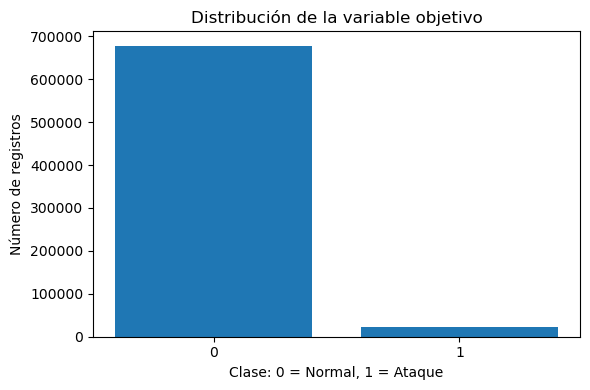

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(label_distribution.index.astype(str), label_distribution["cantidad"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase: 0 = Normal, 1 = Ataque")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.savefig("fig_distribucion_label.png", dpi=300, bbox_inches="tight")
plt.show()

### Hallazgo: desbalance de clases

La distribución de `label` muestra un desbalance entre tráfico normal y tráfico malicioso. Esto implica que accuracy no debe ser la única métrica de evaluación, ya que un modelo podría obtener un valor alto simplemente clasificando la mayoría de observaciones como normales.

Por esta razón, se incluirán métricas adicionales como precision, recall y F1-score. Además, en Random Forest se evaluará el uso de `class_weight='balanced'` para compensar parcialmente el desbalance durante el entrenamiento.

## 5. Distribución por categoría de ataque

Aunque el modelo principal se plantea como una clasificación binaria, la variable `attack_cat` permite entender la composición de los ataques presentes en el dataset.

Esta variable se utilizará solo para análisis exploratorio y no será incluida en el entrenamiento, ya que representa información posterior asociada al tipo de ataque.

In [14]:
# ============================================================
# 9. Distribución por categoría de ataque
# ============================================================

if "attack_cat" in df.columns:
    attack_distribution = df["attack_cat"].value_counts()
    display(attack_distribution)

attack_cat
Generic           7522
Exploits          5409
 Fuzzers          5051
Reconnaissance    1759
DoS               1167
Backdoors          534
Analysis           526
Shellcode          223
Worms               24
Name: count, dtype: int64

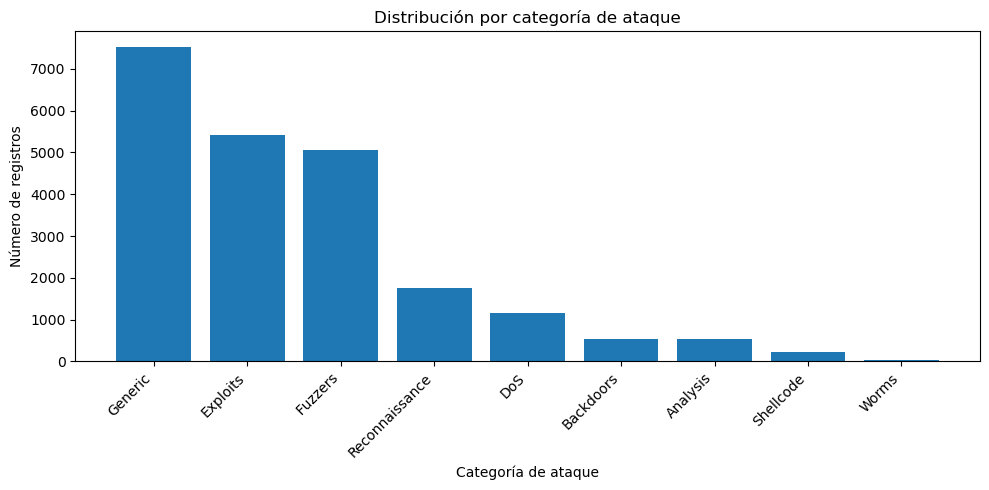

In [15]:
if "attack_cat" in df.columns:
    plt.figure(figsize=(10, 5))
    plt.bar(attack_distribution.index.astype(str), attack_distribution.values)
    plt.title("Distribución por categoría de ataque")
    plt.xlabel("Categoría de ataque")
    plt.ylabel("Número de registros")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_distribucion_attack_cat.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Correlación con la variable objetivo

Se analiza la correlación de variables numéricas respecto a `label`. Este análisis permite identificar variables potencialmente relevantes para la clasificación.

Sin embargo, una alta correlación no implica necesariamente que la variable deba eliminarse. En esta etapa, el objetivo es identificar posibles redundancias o variables dominantes, pero se prioriza mantener el valor predictivo para el primer pipeline experimental.

In [16]:
# ============================================================
# 10. Correlación con label
# ============================================================

numeric_df = df.select_dtypes(include=[np.number]).copy()

corr_with_label = (
    numeric_df
    .corr(numeric_only=True)["Label"]
    .drop("Label", errors="ignore")
    .sort_values(ascending=False)
)

corr_with_label.head(15)

sttl               0.8366
ct_state_ttl       0.7429
dttl               0.4540
tcprtt             0.3314
ackdat             0.3290
synack             0.2963
Sload              0.2536
ct_dst_sport_ltm   0.1104
ct_src_dport_ltm   0.1062
Sjit               0.0755
ct_dst_src_ltm     0.0539
sbytes             0.0325
ct_srv_src         0.0301
ct_srv_dst         0.0238
smeansz            0.0218
Name: Label, dtype: float64

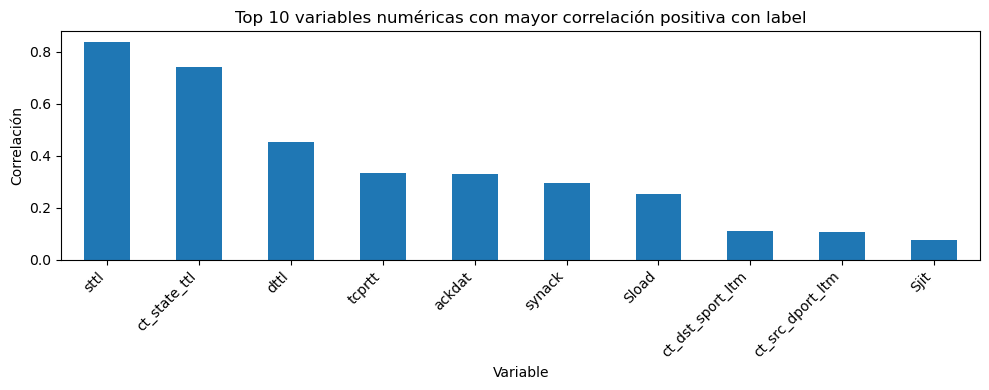

In [17]:
plt.figure(figsize=(10, 4))
corr_with_label.head(10).plot(kind="bar")
plt.title("Top 10 variables numéricas con mayor correlación positiva con label")
plt.xlabel("Variable")
plt.ylabel("Correlación")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fig_correlacion_label.png", dpi=300, bbox_inches="tight")
plt.show()

### Decisión sobre variables altamente correlacionadas

Se identifican variables con alta correlación respecto a `label`.

## 7. Definición de escenarios experimentales

A partir del análisis exploratorio, se definen dos escenarios locales para evaluar el impacto de la optimización a nivel de pipeline completo.

**Escenario 1: Local sin optimización**

Este escenario representa una ejecución base. Se aplican únicamente las transformaciones mínimas necesarias para que los modelos puedan entrenar:

- Exclusión de `attack_cat` para evitar fuga de información.
- Imputación básica de valores faltantes.
- Codificación de variables categóricas.
- Modelos ejecutados sin paralelización explícita (`n_jobs=1`).

No se aplica reducción de memoria, no se ajustan tipos de datos y no se eliminan variables por cardinalidad.

**Escenario 3: Local optimizado**

Este escenario incorpora optimizaciones tanto en el procesamiento de datos como en el entrenamiento:

- Eliminación de `srcip` y `dstip` por alta cardinalidad.
- Conversión de `sport` y `dsport` a numérico.
- Imputación controlada.
- Codificación categórica.
- Reducción de memoria mediante ajuste de tipos.
- Modelos con paralelización interna (`n_jobs=-1`).
- XGBoost con `tree_method='hist'`.

De esta forma, la comparación ya no se realiza entre modelos aislados, sino entre dos pipelines completos.

In [34]:
# ============================================================
# Definición de datasets por escenario
# ============================================================

df_s1 = df.copy()  # Escenario 1: sin optimización
df_s3 = df.copy()  # Escenario 3: optimizado

print("Shape Escenario 1:", df_s1.shape)
print("Shape Escenario 3:", df_s3.shape)

Shape Escenario 1: (700001, 49)
Shape Escenario 3: (700001, 49)


## Escenario 1: Pipeline local sin optimización

En este escenario se prepara el dataset aplicando solo las transformaciones mínimas requeridas para el entrenamiento. No se realiza optimización de memoria ni eliminación de variables de alta cardinalidad.

Este escenario funciona como línea base para comparar el impacto del pipeline optimizado.

In [36]:
# ============================================================
# Escenario 1: preprocesamiento mínimo
# ============================================================

target_col = "Label"

# Se excluye attack_cat para evitar fuga de información
if "attack_cat" in df_s1.columns:
    df_s1 = df_s1.drop(columns=["attack_cat"])

# Imputación básica
for col in df_s1.select_dtypes(include=[np.number]).columns:
    if df_s1[col].isnull().sum() > 0:
        df_s1[col] = df_s1[col].fillna(df_s1[col].median())

for col in df_s1.select_dtypes(include=["object", "category"]).columns:
    if df_s1[col].isnull().sum() > 0:
        df_s1[col] = df_s1[col].fillna("unknown")

# Codificación categórica mínima
categorical_cols_s1 = df_s1.select_dtypes(include=["object", "category"]).columns.tolist()

label_encoders_s1 = {}

for col in categorical_cols_s1:
    le = LabelEncoder()
    df_s1[col] = le.fit_transform(df_s1[col].astype(str))
    label_encoders_s1[col] = le

X_s1 = df_s1.drop(columns=[target_col])
y_s1 = df_s1[target_col]

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1,
    y_s1,
    test_size=0.2,
    random_state=42,
    stratify=y_s1
)

print("Escenario 1 - Train:", X_train_s1.shape)
print("Escenario 1 - Test:", X_test_s1.shape)
print("Variables categóricas codificadas S1:", categorical_cols_s1)

Escenario 1 - Train: (560000, 47)
Escenario 1 - Test: (140001, 47)
Variables categóricas codificadas S1: []


## Escenario 3: Pipeline local optimizado

En este escenario se aplican optimizaciones sobre el dataset y sobre el entrenamiento de modelos. El objetivo es reducir consumo de memoria y tiempos de ejecución sin comprometer el desempeño predictivo.

In [37]:
# ============================================================
# Escenario 3: preprocesamiento optimizado
# ============================================================

# Exclusión de variables de alta cardinalidad
cols_high_cardinality = ["srcip", "dstip"]
df_s3 = df_s3.drop(columns=[col for col in cols_high_cardinality if col in df_s3.columns])

# Exclusión de attack_cat para evitar fuga de información
if "attack_cat" in df_s3.columns:
    df_s3 = df_s3.drop(columns=["attack_cat"])

# Conversión de puertos a numérico
for col in ["sport", "dsport"]:
    if col in df_s3.columns:
        df_s3[col] = pd.to_numeric(df_s3[col], errors="coerce")

# Imputación controlada
for col in df_s3.select_dtypes(include=[np.number]).columns:
    if df_s3[col].isnull().sum() > 0:
        df_s3[col] = df_s3[col].fillna(df_s3[col].median())

for col in df_s3.select_dtypes(include=["object", "category"]).columns:
    if df_s3[col].isnull().sum() > 0:
        df_s3[col] = df_s3[col].fillna("unknown")

# Codificación categórica
categorical_cols_s3 = df_s3.select_dtypes(include=["object", "category"]).columns.tolist()

label_encoders_s3 = {}

for col in categorical_cols_s3:
    le = LabelEncoder()
    df_s3[col] = le.fit_transform(df_s3[col].astype(str))
    label_encoders_s3[col] = le

print("Variables categóricas codificadas S3:", categorical_cols_s3)
print("Dimensiones antes de optimización de memoria:", df_s3.shape)

Variables categóricas codificadas S3: ['proto', 'state', 'service']
Dimensiones antes de optimización de memoria: (700001, 46)


In [38]:
# ============================================================
# Escenario 3: optimización de memoria
# ============================================================

def reduce_memory_usage(df_input):
    df_opt = df_input.copy()
    
    for col in df_opt.select_dtypes(include=["int64"]).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast="integer")
        
    for col in df_opt.select_dtypes(include=["float64"]).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast="float")
        
    return df_opt


memory_before_s3 = df_s3.memory_usage(deep=True).sum() / (1024 ** 2)

df_s3 = reduce_memory_usage(df_s3)

memory_after_s3 = df_s3.memory_usage(deep=True).sum() / (1024 ** 2)

memory_optimization_summary = pd.DataFrame({
    "escenario": ["Escenario 3 - Optimizado"],
    "memoria_antes_mb": [round(memory_before_s3, 2)],
    "memoria_despues_mb": [round(memory_after_s3, 2)],
    "reduccion_porcentual": [round((1 - memory_after_s3 / memory_before_s3) * 100, 2)]
})

memory_optimization_summary

,escenario,memoria_antes_mb,memoria_despues_mb,reduccion_porcentual
0,Escenario 3 - Optimizado,245.6700,92.1300,62.5000


## 8. Definición del dataset final

Luego del preprocesamiento, se define el dataset final para entrenamiento. La variable objetivo es `label`, mientras que el resto de variables se utilizan como predictores.

In [39]:
# ============================================================
# Escenario 3: división train/test
# ============================================================

X_s3 = df_s3.drop(columns=[target_col])
y_s3 = df_s3[target_col]

X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X_s3,
    y_s3,
    test_size=0.2,
    random_state=42,
    stratify=y_s3
)

print("Escenario 3 - Train:", X_train_s3.shape)
print("Escenario 3 - Test:", X_test_s3.shape)

Escenario 3 - Train: (560000, 45)
Escenario 3 - Test: (140001, 45)


## 9. Escalado para MLP

El modelo MLPClassifier es sensible a la escala de las variables, por lo que se aplica estandarización únicamente para este modelo.

Random Forest y XGBoost no requieren escalado de forma estricta, ya que están basados en árboles.

In [40]:
# ============================================================
# Escalado para MLP por escenario
# ============================================================

scaler_s1 = StandardScaler()
X_train_s1_scaled = scaler_s1.fit_transform(X_train_s1)
X_test_s1_scaled = scaler_s1.transform(X_test_s1)

scaler_s3 = StandardScaler()
X_train_s3_scaled = scaler_s3.fit_transform(X_train_s3)
X_test_s3_scaled = scaler_s3.transform(X_test_s3)

## 10. Modelos base sin optimización

En este escenario se entrenan los modelos con una configuración base. Para los modelos que permiten paralelización explícita, se usa `n_jobs=1`.

Este escenario funciona como línea base para comparar posteriormente el impacto de la optimización.

In [41]:
# ============================================================
# Modelos Escenario 1: Local sin optimización
# ============================================================

models_s1 = {
    "Random Forest - S1 Sin Optimización": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    "XGBoost - S1 Sin Optimización": XGBClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    ),
    "MLP - S1 Sin Optimización": MLPClassifier(
        hidden_layer_sizes=(64,),
        max_iter=50,
        random_state=42
    )
}

## 11. Modelos optimizados

En este escenario se aplica paralelización interna mediante `n_jobs=-1` en los modelos que lo permiten. Esta configuración permite aprovechar todos los núcleos disponibles del CPU.

Para XGBoost también se utiliza `tree_method='hist'`, una estrategia eficiente para entrenamiento con datos tabulares.

In [42]:
# ============================================================
# Modelos Escenario 3: Local optimizado
# ============================================================

models_s3 = {
    "Random Forest - S3 Optimizado": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "XGBoost - S3 Optimizado": XGBClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        eval_metric="logloss"
    ),
    "MLP - S3 Optimizado": MLPClassifier(
        hidden_layer_sizes=(64,),
        max_iter=50,
        random_state=42
    )
}

In [43]:
# ============================================================
# Función de entrenamiento y evaluación
# ============================================================

def train_and_evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name, scenario):
    results = {}
    
    # Entrenamiento
    train_start = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    train_end = time.perf_counter()
    train_resources = get_resource_usage()
    
    # Inferencia
    pred_start = time.perf_counter()
    y_pred = model.predict(X_test_data)
    pred_end = time.perf_counter()
    pred_resources = get_resource_usage()
    
    results["scenario"] = scenario
    results["model"] = model_name
    results["train_time_sec"] = train_end - train_start
    results["inference_time_sec"] = pred_end - pred_start
    results["accuracy"] = accuracy_score(y_test_data, y_pred)
    results["precision"] = precision_score(y_test_data, y_pred, zero_division=0)
    results["recall"] = recall_score(y_test_data, y_pred, zero_division=0)
    results["f1_score"] = f1_score(y_test_data, y_pred, zero_division=0)
    results["cpu_train_percent"] = train_resources["cpu_percent"]
    results["ram_train_gb"] = train_resources["ram_used_gb"]
    results["cpu_pred_percent"] = pred_resources["cpu_percent"]
    results["ram_pred_gb"] = pred_resources["ram_used_gb"]
    
    return results, y_pred

In [44]:
# ============================================================
# Entrenamiento y evaluación por escenario
# ============================================================

results_all = []

# Escenario 1
for name, model in models_s1.items():
    print(f"Entrenando {name}...")
    
    if "MLP" in name:
        result, _ = train_and_evaluate_model(
            model,
            X_train_s1_scaled,
            X_test_s1_scaled,
            y_train_s1,
            y_test_s1,
            name,
            "Escenario 1 - Local sin optimización"
        )
    else:
        result, _ = train_and_evaluate_model(
            model,
            X_train_s1,
            X_test_s1,
            y_train_s1,
            y_test_s1,
            name,
            "Escenario 1 - Local sin optimización"
        )
    
    results_all.append(result)


# Escenario 3
for name, model in models_s3.items():
    print(f"Entrenando {name}...")
    
    if "MLP" in name:
        result, _ = train_and_evaluate_model(
            model,
            X_train_s3_scaled,
            X_test_s3_scaled,
            y_train_s3,
            y_test_s3,
            name,
            "Escenario 3 - Local optimizado"
        )
    else:
        result, _ = train_and_evaluate_model(
            model,
            X_train_s3,
            X_test_s3,
            y_train_s3,
            y_test_s3,
            name,
            "Escenario 3 - Local optimizado"
        )
    
    results_all.append(result)

results_df = pd.DataFrame(results_all)
results_df

Entrenando Random Forest - S1 Sin Optimización...
Entrenando XGBoost - S1 Sin Optimización...
Entrenando MLP - S1 Sin Optimización...
Entrenando Random Forest - S3 Optimizado...
Entrenando XGBoost - S3 Optimizado...
Entrenando MLP - S3 Optimizado...


,scenario,model,train_time_sec,inference_time_sec,accuracy,precision,recall,f1_score,cpu_train_percent,ram_train_gb,cpu_pred_percent,ram_pred_gb
0,Escenario 1 - Local sin optimización,Random Forest - S1 Sin Optimización,45.7964,0.7286,0.9986,0.9684,0.9874,0.9778,5.8000,18.1673,1.9000,18.1911
1,Escenario 1 - Local sin optimización,XGBoost - S1 Sin Optimización,9.1863,0.1878,0.9987,0.9733,0.9847,0.9790,2.0000,18.0919,3.2000,18.0700
2,Escenario 1 - Local sin optimización,MLP - S1 Sin Optimización,59.1933,0.2393,0.9969,0.9461,0.9552,0.9506,4.0000,17.9044,3.1000,17.8783
3,Escenario 3 - Local optimizado,Random Forest - S3 Optimizado,7.6010,0.1324,0.9983,0.9728,0.9750,0.9739,2.1000,17.9035,3.3000,17.8814
4,Escenario 3 - Local optimizado,XGBoost - S3 Optimizado,1.7906,0.0489,0.9985,0.9719,0.9800,0.9759,11.2000,17.9345,12.4000,17.9188
5,Escenario 3 - Local optimizado,MLP - S3 Optimizado,62.1216,0.1298,0.9964,0.9428,0.9426,0.9427,2.5000,18.1243,4.7000,18.1305


## 12. Comparación de resultados

Se consolidan los resultados de los modelos base y optimizados para comparar:

- Tiempo de entrenamiento.
- Tiempo de inferencia.
- F1-score.
- Uso de recursos.

Esta comparación permite evaluar si las optimizaciones reducen el tiempo de ejecución sin comprometer la calidad predictiva.

In [45]:
# ============================================================
# Comparación Escenario 1 vs Escenario 3
# ============================================================

comparison_rows = []

model_map = {
    "Random Forest": (
        "Random Forest - S1 Sin Optimización",
        "Random Forest - S3 Optimizado"
    ),
    "XGBoost": (
        "XGBoost - S1 Sin Optimización",
        "XGBoost - S3 Optimizado"
    ),
    "MLP": (
        "MLP - S1 Sin Optimización",
        "MLP - S3 Optimizado"
    )
}

for model_name, (s1_name, s3_name) in model_map.items():
    s1_row = results_df[results_df["model"] == s1_name].iloc[0]
    s3_row = results_df[results_df["model"] == s3_name].iloc[0]
    
    train_reduction = (
        (s1_row["train_time_sec"] - s3_row["train_time_sec"])
        / s1_row["train_time_sec"]
    ) * 100
    
    inference_reduction = (
        (s1_row["inference_time_sec"] - s3_row["inference_time_sec"])
        / s1_row["inference_time_sec"]
    ) * 100
    
    comparison_rows.append({
        "model": model_name,
        "s1_train_time_sec": s1_row["train_time_sec"],
        "s3_train_time_sec": s3_row["train_time_sec"],
        "train_time_reduction_pct": train_reduction,
        "s1_inference_time_sec": s1_row["inference_time_sec"],
        "s3_inference_time_sec": s3_row["inference_time_sec"],
        "inference_time_reduction_pct": inference_reduction,
        "s1_f1": s1_row["f1_score"],
        "s3_f1": s3_row["f1_score"]
    })

optimization_comparison_df = pd.DataFrame(comparison_rows)
optimization_comparison_df

,model,s1_train_time_sec,s3_train_time_sec,train_time_reduction_pct,s1_inference_time_sec,s3_inference_time_sec,inference_time_reduction_pct,s1_f1,s3_f1
0,Random Forest,45.7964,7.6010,83.4027,0.7286,0.1324,81.8288,0.9778,0.9739
1,XGBoost,9.1863,1.7906,80.5074,0.1878,0.0489,73.9459,0.9790,0.9759
2,MLP,59.1933,62.1216,-4.9470,0.2393,0.1298,45.7453,0.9506,0.9427


In [46]:
# ============================================================
# Exportación de tablas para LaTeX
# ============================================================

results_df.to_csv("tabla_resultados_escenarios_locales.csv", index=False)
optimization_comparison_df.to_csv("tabla_comparacion_s1_s3.csv", index=False)
memory_optimization_summary.to_csv("tabla_optimizacion_memoria_s3.csv", index=False)

Exportacion de gráficos

<Figure size 1000x500 with 0 Axes>

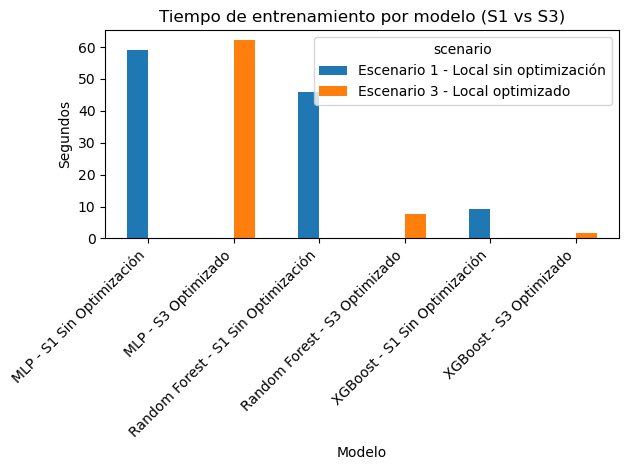

In [47]:
plt.figure(figsize=(10, 5))

pivot_train = results_df.pivot(index="model", columns="scenario", values="train_time_sec")
pivot_train.plot(kind="bar")

plt.title("Tiempo de entrenamiento por modelo (S1 vs S3)")
plt.ylabel("Segundos")
plt.xlabel("Modelo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("fig_train_time_s1_vs_s3.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x500 with 0 Axes>

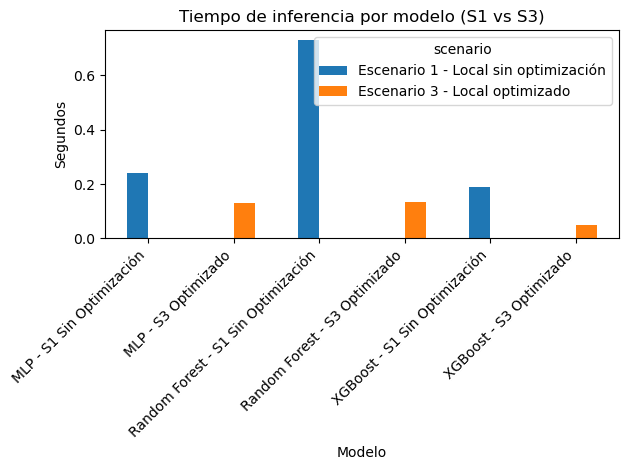

In [48]:
plt.figure(figsize=(10, 5))

pivot_inf = results_df.pivot(index="model", columns="scenario", values="inference_time_sec")
pivot_inf.plot(kind="bar")

plt.title("Tiempo de inferencia por modelo (S1 vs S3)")
plt.ylabel("Segundos")
plt.xlabel("Modelo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("fig_inference_time_s1_vs_s3.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x500 with 0 Axes>

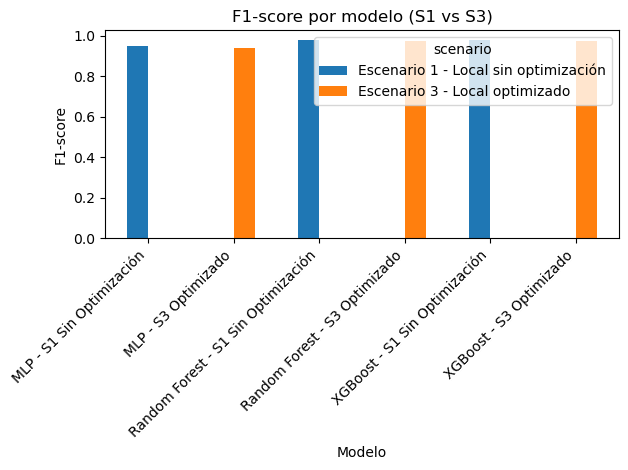

In [49]:
plt.figure(figsize=(10, 5))

pivot_f1 = results_df.pivot(index="model", columns="scenario", values="f1_score")
pivot_f1.plot(kind="bar")

plt.title("F1-score por modelo (S1 vs S3)")
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("fig_f1_s1_vs_s3.png", dpi=300, bbox_inches="tight")
plt.show()

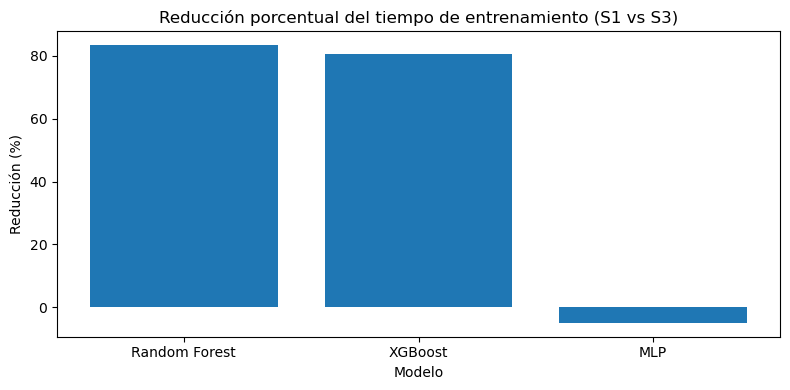

In [50]:
plt.figure(figsize=(8, 4))

plt.bar(
    optimization_comparison_df["model"],
    optimization_comparison_df["train_time_reduction_pct"]
)

plt.title("Reducción porcentual del tiempo de entrenamiento (S1 vs S3)")
plt.ylabel("Reducción (%)")
plt.xlabel("Modelo")

plt.tight_layout()
plt.savefig("fig_reduction_pct.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x500 with 0 Axes>

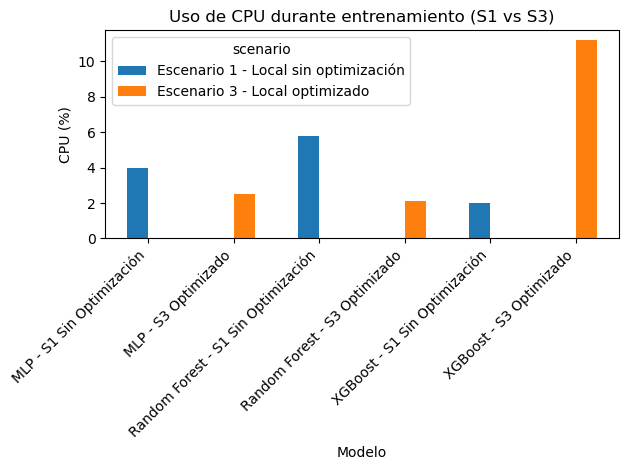

In [51]:
plt.figure(figsize=(10, 5))

pivot_cpu = results_df.pivot(index="model", columns="scenario", values="cpu_train_percent")
pivot_cpu.plot(kind="bar")

plt.title("Uso de CPU durante entrenamiento (S1 vs S3)")
plt.ylabel("CPU (%)")
plt.xlabel("Modelo")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("fig_cpu_train_s1_vs_s3.png", dpi=300, bbox_inches="tight")
plt.show()